In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 130


In [2]:
from google.colab import files
uploaded = files.upload()  # select wine.csv

fname = list(uploaded.keys())[0]
df = pd.read_csv(fname)
print("Loaded:", fname, "| Shape:", df.shape)
display(df.head())
print("\nColumns:", df.columns.tolist())


Saving wine.csv to wine.csv
Loaded: wine.csv | Shape: (2247, 19)


,name,price (PLN),country,region,appellation,vineyard,vintage,volume (liters),alcohol (%),serving temperature (C),color,kind,taste,style,medals,wegan,natural,punctation,grapes
0,Szampan Moet & Chandon Brut Imperial Magnum w ...,666.0,France,Champagne,Champagne AOC,Moet & Chandon,NaN,1.50,NaN,9,NaN,champagne,dry,average,NaN,False,False,NaN,Chardonnay
1,11 Filari Primitivo di Manduria San Marzano,109.0,Italy,Puglia,Primitivo di Manduria DOP,NaN,2017.0,0.50,17.5,18,red,NaN,sweet,full,NaN,False,False,NaN,Primitivo
2,Szampan Moet & Chandon Brut Imperial Jeroboam ...,1999.0,France,Champagne,Champagne AOC,Moet & Chandon,NaN,3.00,NaN,9,NaN,champagne,dry,average,NaN,False,False,NaN,Chardonnay
3,770 Miles Zinfandel California,37.0,United States of America,California,NaN,NaN,2021.0,0.75,13.5,16-18,red,NaN,dry,average,NaN,False,False,NaN,Zinfandel
4,770 Miles Zinfandel Rose California,39.0,United States of America,California,NaN,NaN,2021.0,0.75,10.0,8-10,rose,NaN,semi-dry,light,NaN,False,False,NaN,Zinfandel



Columns: ['name', 'price (PLN)', 'country', 'region', 'appellation', 'vineyard', 'vintage', 'volume (liters)', 'alcohol (%)', 'serving temperature (C)', 'color', 'kind', 'taste', 'style', 'medals', 'wegan', 'natural', 'punctation', 'grapes']


In [3]:
print("INFO:")
df.info()
print("\nNA counts:")
print(df.isna().sum())

# Try to detect important columns (robust)
col_country = [c for c in df.columns if "country" in c.lower()][0]
col_vintage = [c for c in df.columns if "vintage" in c.lower()][0]
col_alcohol = [c for c in df.columns if "alcohol" in c.lower()][0]
col_price   = [c for c in df.columns if "price" in c.lower()][0]
col_volume  = [c for c in df.columns if "volume" in c.lower()][0]

print("\nDetected key columns:")
print(" country ->", col_country)
print(" vintage ->", col_vintage)
print(" alcohol ->", col_alcohol)
print(" price   ->", col_price)
print(" volume  ->", col_volume)


INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2247 entries, 0 to 2246
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   name                     2247 non-null   object 
 1   price (PLN)              2247 non-null   float64
 2   country                  2239 non-null   object 
 3   region                   2079 non-null   object 
 4   appellation              1631 non-null   object 
 5   vineyard                 1228 non-null   object 
 6   vintage                  1974 non-null   float64
 7   volume (liters)          2179 non-null   float64
 8   alcohol (%)              1723 non-null   float64
 9   serving temperature (C)  1777 non-null   object 
 10  color                    1997 non-null   object 
 11  kind                     254 non-null    object 
 12  taste                    2195 non-null   object 
 13  style                    1808 non-null   object 
 14  medals            

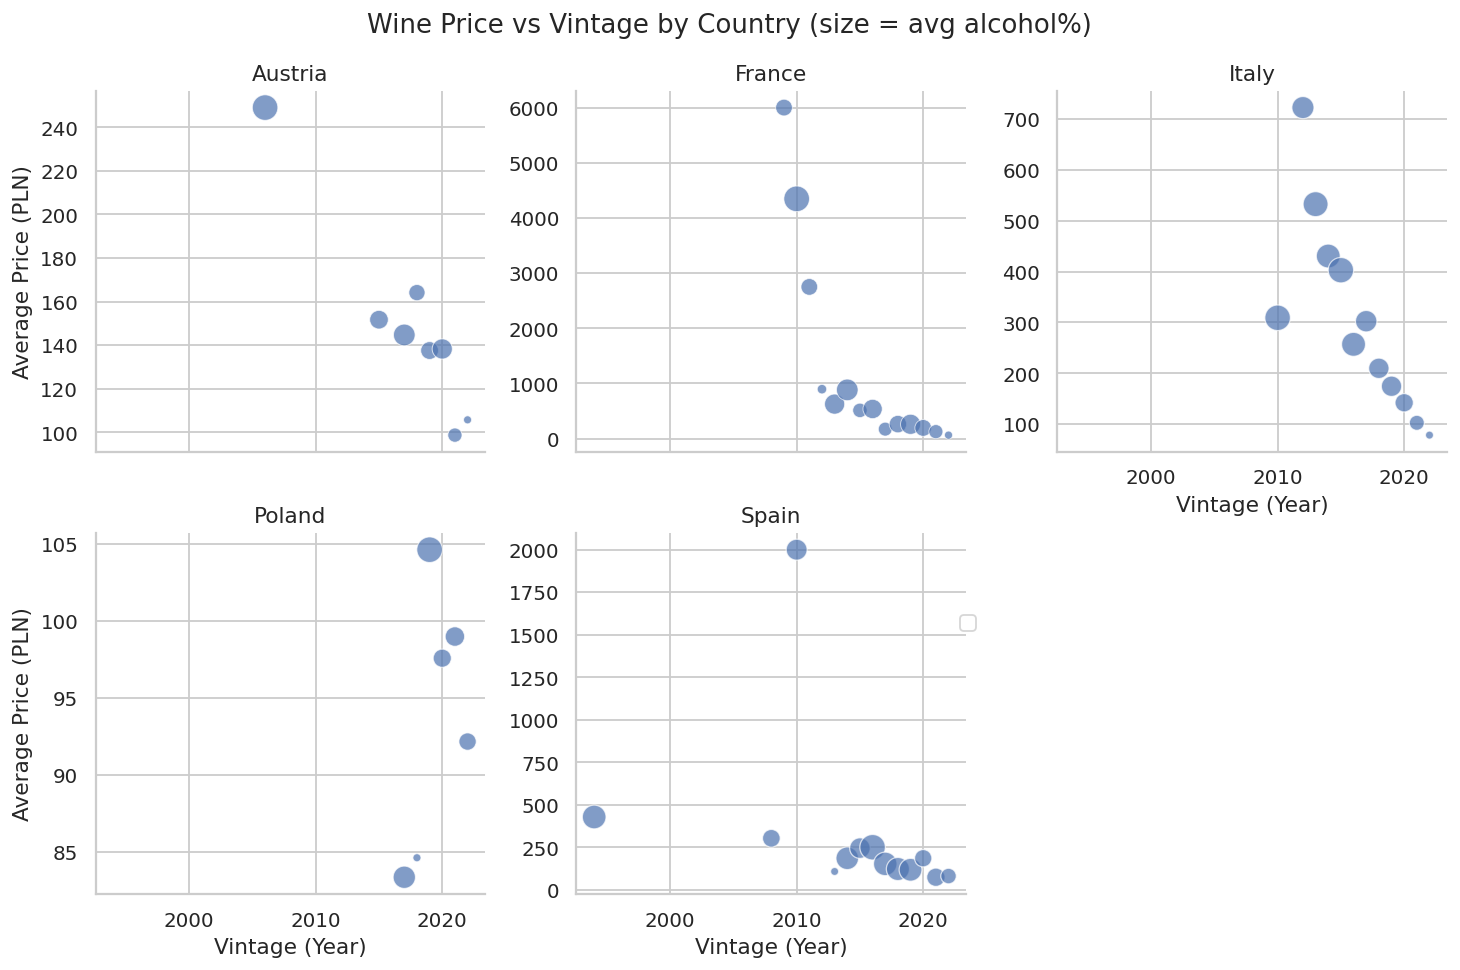

In [4]:
# Keep top 5 countries
top_countries = df[col_country].value_counts().head(5).index
sub = df[df[col_country].isin(top_countries)].copy()

# Group by country+vintage, aggregate mean price & mean alcohol
agg = (sub.groupby([col_country, col_vintage])
          .agg(avg_price=(col_price,"mean"), avg_alcohol=(col_alcohol,"mean"))
          .reset_index())

# Plot FacetGrid: scatter, vintage vs price, size=alcohol
g = sns.FacetGrid(agg, col=col_country, col_wrap=3, sharey=False, height=3.8)
g.map_dataframe(sns.scatterplot, x=col_vintage, y="avg_price", size="avg_alcohol",
                sizes=(20,200), alpha=0.7, legend=False)

g.set_axis_labels("Vintage (Year)", "Average Price (PLN)")
g.set_titles(col_template="{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Wine Price vs Vintage by Country (size = avg alcohol%)")

# Add legend separately
plt.legend(*g.axes[0].get_legend_handles_labels(), bbox_to_anchor=(1.05, 0.8))
plt.show()


RMSE: 158.03 | R²: 0.754


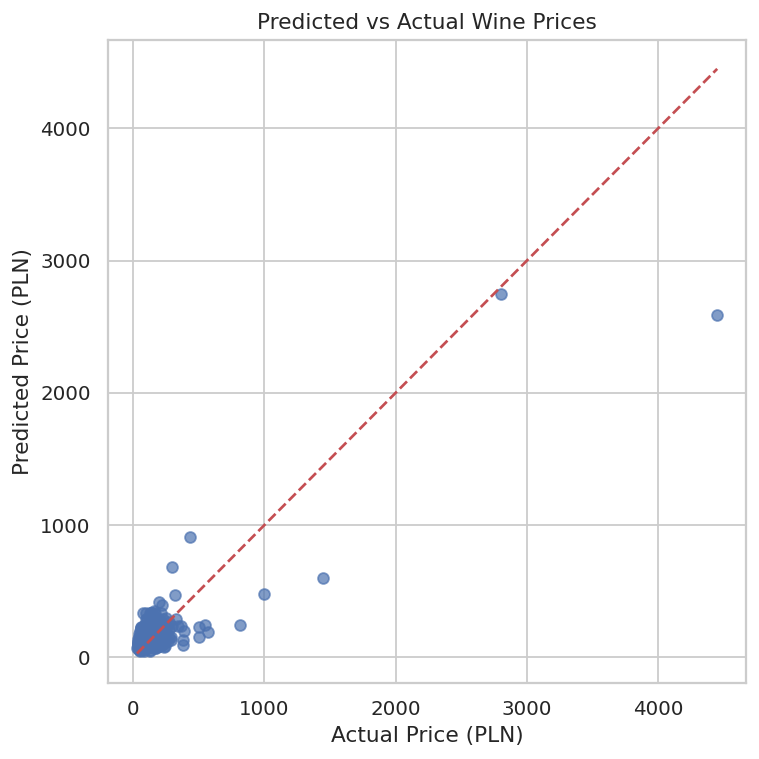

In [6]:
# Features and target
X = df[[col_country, col_vintage, col_volume, col_alcohol]].copy()
y = df[col_price]

# Handle missing values
X = X.dropna()
y = y.loc[X.index]

# Categorical vs numeric columns
cat_cols = [col_country]
num_cols = [col_vintage, col_volume, col_alcohol]

# Preprocessor: one-hot + scale
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

# Model (Random Forest)
reg = RandomForestRegressor(n_estimators=200, random_state=42)

pipe = Pipeline([
    ("prep", preprocessor),
    ("model", reg)
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit + predict
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

# --- FIX: compute RMSE manually ---
mse = mean_squared_error(y_test, y_pred)  # plain MSE
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f} | R²: {r2:.3f}")

# Scatter: predicted vs actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Price (PLN)")
plt.ylabel("Predicted Price (PLN)")
plt.title("Predicted vs Actual Wine Prices")
plt.tight_layout()
plt.show()


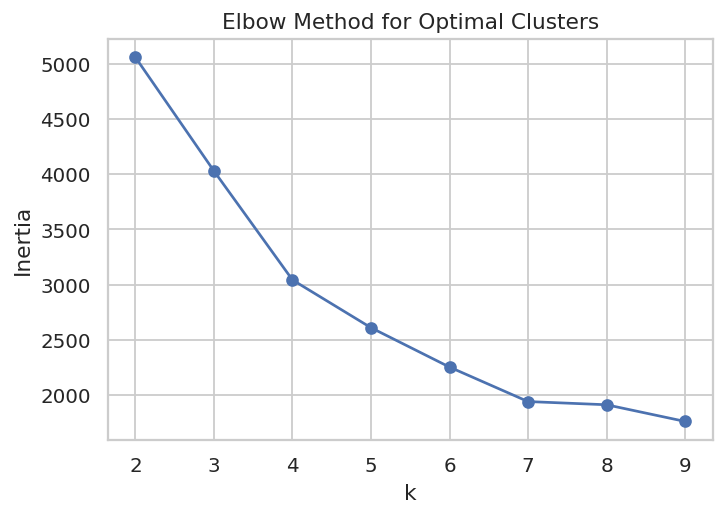

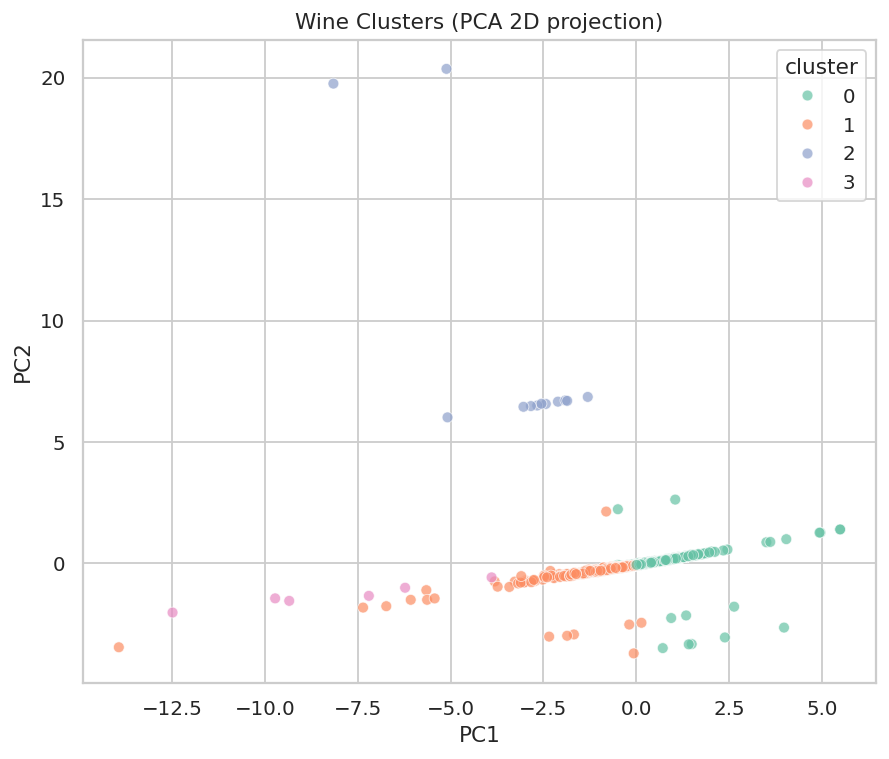

Cluster summary (avg values):


,alcohol (%),volume (liters),vintage,price (PLN)
cluster,,,,
0,12.526027,0.747602,2020.416479,107.550779
1,13.941349,0.747738,2017.638158,203.100164
2,13.958333,1.750000,2016.916667,336.000000
3,13.750000,0.750000,2014.500000,4107.500000


In [7]:
# Prepare clustering dataset
clust = df[[col_alcohol,col_volume,col_vintage,col_price]].dropna().copy()

# Normalize
scaler = StandardScaler()
clust_scaled = scaler.fit_transform(clust)

# Elbow method
inertia = []
K = range(2,10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(clust_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, "o-")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Clusters")
plt.show()

# Example: k=4
k_opt = 4
km = KMeans(n_clusters=k_opt, random_state=42, n_init="auto")
labels = km.fit_predict(clust_scaled)

# PCA 2D projection
pca = PCA(n_components=2)
proj = pca.fit_transform(clust_scaled)
proj_df = pd.DataFrame(proj, columns=["PC1","PC2"])
proj_df["cluster"] = labels

plt.figure(figsize=(7,6))
sns.scatterplot(data=proj_df, x="PC1", y="PC2", hue="cluster", palette="Set2", alpha=0.7)
plt.title("Wine Clusters (PCA 2D projection)")
plt.tight_layout()
plt.show()

# Cluster summary
clust["cluster"] = labels
cluster_summary = clust.groupby("cluster").mean()
print("Cluster summary (avg values):")
display(cluster_summary)
